In [2]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings("ignore")

In [3]:
import torch
import STAGATE_pyG

In [5]:
adata_list = {}

In [9]:
input_dir = 'data'
counts_file = os.path.join(input_dir, 'Puck_200127_15.digital_expression.txt')
coor_file = os.path.join(input_dir, 'Puck_200127_15_bead_locations.csv')

In [10]:
counts = pd.read_csv(counts_file, sep='\t', index_col=0)
coor_df = pd.read_csv(coor_file, index_col=0)
print(counts.shape, coor_df.shape)

(21220, 21724) (21724, 3)


In [11]:
adata = sc.AnnData(counts.T)
adata.var_names_make_unique()
coor_df = coor_df.set_index('barcode')
coor_df = coor_df.loc[adata.obs_names, ['xcoord', 'ycoord']]
adata.obsm["spatial"] = coor_df.to_numpy()

In [12]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [13]:
adata


AnnData object with n_obs × n_vars = 21724 × 21220
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

(np.float64(-289.81710000000004),
 np.float64(6312.7151),
 np.float64(173.30850000000004),
 np.float64(5709.8615))

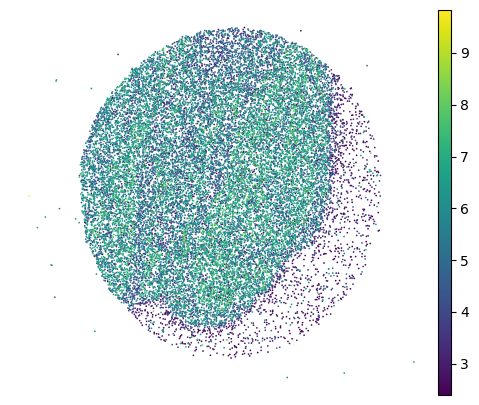

In [14]:
plt.rcParams["figure.figsize"] = (6,5)
sc.pl.embedding(adata, basis="spatial", color="log1p_total_counts",s=6, show=False)
plt.title('')
plt.axis('off')

In [15]:
# can be downloaded from https://drive.google.com/drive/folders/10lhz5VY7YfvHrtV40MwaqLmWz56U9eBP?usp=sharing
used_barcode = pd.read_csv(os.path.join(input_dir, 'used_barcodes.txt'), sep='\t', header=None)
used_barcode = used_barcode[0]

In [16]:
adata = adata[used_barcode,]
adata

View of AnnData object with n_obs × n_vars = 20139 × 21220
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

(np.float64(588.545),
 np.float64(5108.555),
 np.float64(847.6700000000001),
 np.float64(5670.73))

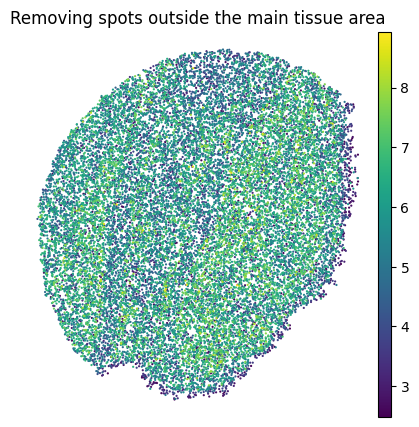

In [17]:
plt.rcParams["figure.figsize"] = (5,5)
sc.pl.embedding(adata, basis="spatial", color="log1p_total_counts",s=10, show=False, title='Removing spots outside the main tissue area')

plt.axis('off')

In [18]:
sc.pp.filter_genes(adata, min_cells=50)
print('After flitering: ', adata.shape)

After flitering:  (20139, 11750)


In [19]:
# make spot name unique
adata.obs_names = [x+'_SlideSeqV2' for x in adata.obs_names]

In [20]:
adata_list['SlideSeqV2'] = adata.copy()

In [21]:
input_dir = 'data'
counts_file = os.path.join(input_dir, 'RNA_counts.tsv')
coor_file = os.path.join(input_dir, 'position.tsv')

In [22]:
counts = pd.read_csv(counts_file, sep='\t', index_col=0)
coor_df = pd.read_csv(coor_file, sep='\t')
print(counts.shape, coor_df.shape)

(27106, 19527) (19527, 3)


In [23]:
counts.columns = ['Spot_'+str(x) for x in counts.columns]
coor_df.index = coor_df['label'].map(lambda x: 'Spot_'+str(x))
coor_df = coor_df.loc[:, ['x','y']]

In [24]:
coor_df.head()

,x,y
label,,
Spot_1,12555.007833,6307.537859
Spot_2,12623.666667,6297.166667
Spot_3,12589.567164,6302.552239
Spot_4,12642.495050,6307.386139
Spot_5,13003.333333,6307.990991


In [25]:
adata = sc.AnnData(counts.T)
adata.var_names_make_unique()

In [26]:
adata

AnnData object with n_obs × n_vars = 19527 × 27106

In [27]:
coor_df = coor_df.loc[adata.obs_names, ['y', 'x']]
adata.obsm["spatial"] = coor_df.to_numpy()
sc.pp.calculate_qc_metrics(adata, inplace=True)

(np.float64(6002.432692307692),
 np.float64(12486.580128205129),
 np.float64(9908.545833333334),
 np.float64(15086.093055555555))

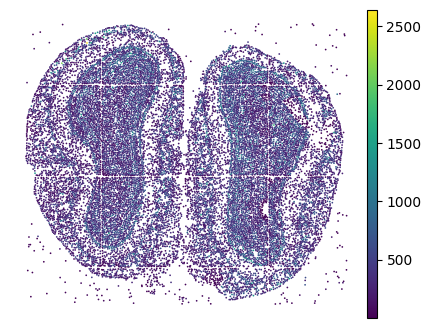

In [28]:
plt.rcParams["figure.figsize"] = (5,4)
sc.pl.embedding(adata, basis="spatial", color="n_genes_by_counts", show=False)
plt.title("")
plt.axis('off')

In [29]:
used_barcode = pd.read_csv(os.path.join(input_dir, 'used_barcodes_stereo_seq.txt'), sep='\t', header=None)
used_barcode = used_barcode[0]
adata = adata[used_barcode,]

In [30]:
adata

View of AnnData object with n_obs × n_vars = 19109 × 27106
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

(np.float64(6005.190789473684),
 np.float64(12428.6600877193),
 np.float64(9986.774763741741),
 np.float64(15062.302776957435))

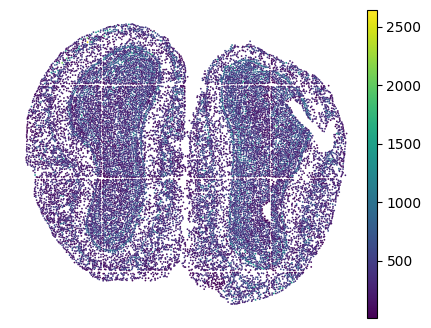

In [31]:
plt.rcParams["figure.figsize"] = (5,4)
sc.pl.embedding(adata, basis="spatial", color="n_genes_by_counts", show=False)
plt.title("")
plt.axis('off')

In [32]:
sc.pp.filter_genes(adata, min_cells=50)
print('After flitering: ', adata.shape)

After flitering:  (19109, 14376)


In [33]:
# make spot name unique
adata.obs_names = [x+'_StereoSeq' for x in adata.obs_names]

In [34]:
adata_list['StereoSeq'] = adata.copy()

------Calculating spatial graph...
The graph contains 228300 edges, 20139 cells.
11.3362 neighbors per cell on average.


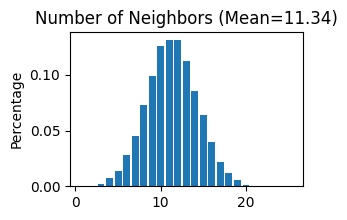

In [36]:
STAGATE_pyG.Cal_Spatial_Net(adata_list['SlideSeqV2'], rad_cutoff=50)
STAGATE_pyG.Stats_Spatial_Net(adata_list['SlideSeqV2'])

------Calculating spatial graph...
The graph contains 144318 edges, 19109 cells.
7.5524 neighbors per cell on average.


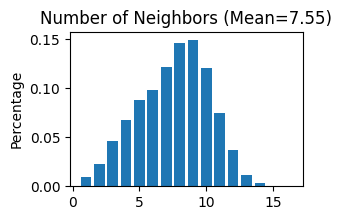

In [37]:
STAGATE_pyG.Cal_Spatial_Net(adata_list['StereoSeq'], rad_cutoff=50)
STAGATE_pyG.Stats_Spatial_Net(adata_list['StereoSeq'])

In [38]:
adata_list['SlideSeqV2'].uns['Spatial_Net']

,Cell1,Cell2,Distance
0,AAAAAAACAAAAGG_SlideSeqV2,ATAAGTTGCCCCGT_SlideSeqV2,41.494698
1,AAAAAAACAAAAGG_SlideSeqV2,CTCCGGGCTCTTCA_SlideSeqV2,44.777226
2,AAAAAAACAAAAGG_SlideSeqV2,CCAGCAAAGCTACA_SlideSeqV2,29.429237
3,AAAAAAACAAAAGG_SlideSeqV2,ACGTTCGCTCATAT_SlideSeqV2,15.307514
4,AAAAAAACAAAAGG_SlideSeqV2,CCTCCTTAACGTTA_SlideSeqV2,33.634060
...,...,...,...
9,TTTTTTTTTTTTAT_SlideSeqV2,CGGCAGGGATCCCT_SlideSeqV2,47.548291
10,TTTTTTTTTTTTAT_SlideSeqV2,TGTATTCACTTTGC_SlideSeqV2,18.753666
11,TTTTTTTTTTTTAT_SlideSeqV2,CCTATAACAGCCTG_SlideSeqV2,30.802922
12,TTTTTTTTTTTTAT_SlideSeqV2,AGTAGTTGCGGCCG_SlideSeqV2,13.688316


In [40]:
adata = sc.concat([adata_list['SlideSeqV2'], adata_list['StereoSeq']], keys=None)

In [41]:
adata.uns['Spatial_Net'] = pd.concat([adata_list['SlideSeqV2'].uns['Spatial_Net'], adata_list['StereoSeq'].uns['Spatial_Net']])

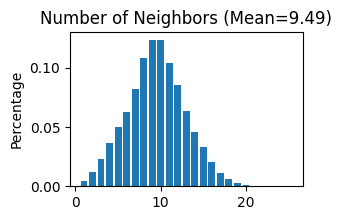

In [46]:
STAGATE_pyG.Stats_Spatial_Net(adata)

In [53]:
import gc
del counts, coor_df
gc.collect()
adata.X = adata.X.astype('float32')
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [57]:
adata = STAGATE_pyG.train_STAGATE(adata, device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'))

Size of Input:  (39248, 3000)


100%|██████████| 1000/1000 [04:24<00:00,  3.77it/s]


In [58]:
sc.pp.neighbors(adata, use_rep='STAGATE')
sc.tl.umap(adata)

In [59]:
adata.obs['Tech'] = [x.split('_')[-1] for x in adata.obs_names]

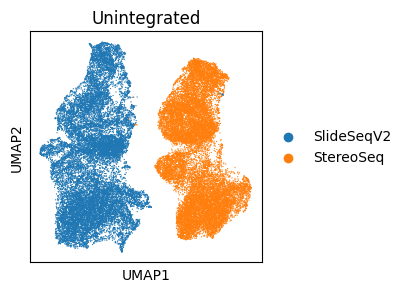

In [60]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.umap(adata, color='Tech', title='Unintegrated')

In [62]:
!{sys.executable} -m pip install harmonypy


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import harmonypy as hm

In [64]:
data_mat = adata.obsm['STAGATE'].copy()
meta_data = adata.obs.copy()

In [65]:
# Run Harmony
ho = hm.run_harmony(data_mat, meta_data, ['Tech'])

2026-03-18 13:19:29,897 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-03-18 13:19:29,898 - harmonypy - INFO -   Parameters:
2026-03-18 13:19:29,899 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-18 13:19:29,899 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-18 13:19:29,899 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-18 13:19:29,899 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-18 13:19:29,900 - harmonypy - INFO -     nclust: 100
2026-03-18 13:19:29,900 - harmonypy - INFO -     block_size: 0.05
2026-03-18 13:19:29,901 - harmonypy - INFO -     lamb: [1. 1.]
2026-03-18 13:19:29,901 - harmonypy - INFO -     theta: [2. 2.]
2026-03-18 13:19:29,903 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-18 13:19:29,903 - harmonypy - INFO -     verbose: True
2026-03-18 13:19:29,904 - harmonypy - INFO -     random_state: 0
2026-03-18 13:19:29,904 - harmonypy - INFO -   Data: 30 PCs × 39248 cells
2026-03-18 13:19:29,904 - harmonypy - INF

In [71]:
print(ho.Z_corr.shape)
print(len(adata.obs_names))

(39248, 30)
39248


In [72]:
res = pd.DataFrame(ho.Z_corr)
res.index = adata.obs_names

In [73]:
adata_Harmony = sc.AnnData(res)

In [74]:
adata_Harmony.obsm['spatial'] = pd.DataFrame(adata.obsm['spatial'], index=adata.obs_names).loc[adata_Harmony.obs_names,].values
adata_Harmony.obs['Tech'] = adata.obs.loc[adata_Harmony.obs_names, 'Tech']

In [75]:
sc.pp.neighbors(adata_Harmony)
sc.tl.umap(adata_Harmony)

In [76]:
sc.tl.leiden(adata_Harmony, resolution=0.8, flavor='igraph', n_iterations=2, directed=False)

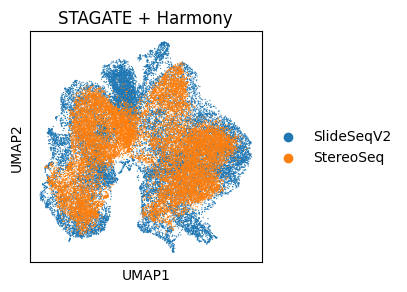

In [77]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.umap(adata_Harmony, color='Tech', title='STAGATE + Harmony')

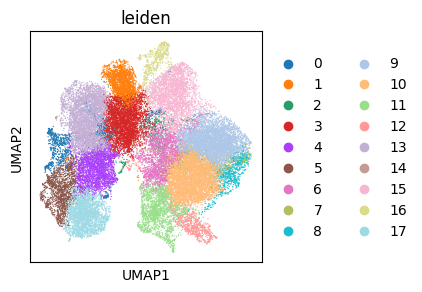

In [78]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.umap(adata_Harmony, color='leiden')

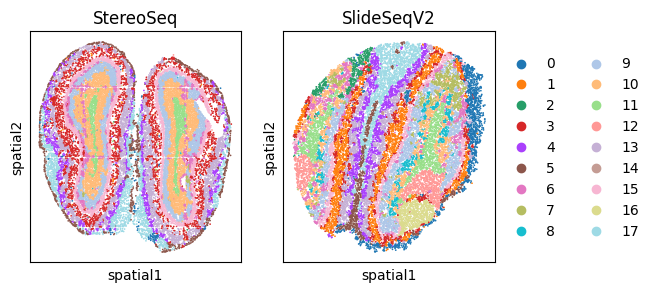

In [79]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3))
it=0
for temp_tech in ['StereoSeq', 'SlideSeqV2']:
    temp_adata = adata_Harmony[adata_Harmony.obs['Tech']==temp_tech, ]
    if it == 1:
        sc.pl.embedding(temp_adata, basis="spatial", color="leiden",s=6, ax=axs[it],
                        show=False, title=temp_tech)
    else:
        sc.pl.embedding(temp_adata, basis="spatial", color="leiden",s=6, ax=axs[it], legend_loc=None,
                        show=False, title=temp_tech)
    it+=1

In [81]:
print(adata)

AnnData object with n_obs × n_vars = 39248 × 10782
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'Tech'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Spatial_Net', 'hvg', 'log1p', 'neighbors', 'umap', 'Tech_colors'
    obsm: 'spatial', 'STAGATE', 'X_umap'
    obsp: 'distances', 'connectivities'


In [83]:
adata_stereo = adata[adata.obs['Tech'] == 'StereoSeq'].copy()
adata_slideseq = adata[adata.obs['Tech'] == 'SlideSeqV2'].copy()
print(adata_stereo.shape, adata_slideseq.shape)

(19109, 10782) (20139, 10782)


In [85]:
adata_stereo = adata[adata.obs['Tech'] == 'StereoSeq'].copy()
STAGATE_pyG.Cal_Spatial_Net(adata_stereo, rad_cutoff=50)

adata_slideseq = adata[adata.obs['Tech'] == 'SlideSeqV2'].copy()
STAGATE_pyG.Cal_Spatial_Net(adata_slideseq, rad_cutoff=50)

------Calculating spatial graph...
The graph contains 144318 edges, 19109 cells.
7.5524 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 228300 edges, 20139 cells.
11.3362 neighbors per cell on average.


In [87]:
from sklearn.metrics import adjusted_rand_score

In [89]:
sc.pp.neighbors(adata_stereo, use_rep='STAGATE')
sc.tl.leiden(adata_stereo, resolution=0.5, flavor='igraph', n_iterations=2, directed=False)

In [90]:
ari_scores_stereo = []
genes_stereo = []
genes_to_test = ['1110002L01Rik', '1600012H06Rik', '1500017E21Rik', 
                 '1110019D14Rik', '1200014J11Rik', '1700008J07Rik',
                 '1500015O10Rik', '0610030E20Rik', '1190005I06Rik', '1500009C09Rik']

for gene in genes_to_test:
    if gene not in adata_stereo.var_names:
        continue  # skip if gene not present in stereo-seq
    adata_perturbed = adata_stereo.copy()
    gene_idx = adata_perturbed.var_names.get_loc(gene)
    X = adata_perturbed.X.toarray()
    X[:, gene_idx] = 0
    adata_perturbed.X = sp.csr_matrix(X)
    adata_perturbed = STAGATE_pyG.train_STAGATE(adata_perturbed, device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'))
    sc.pp.neighbors(adata_perturbed, use_rep='STAGATE')
    sc.tl.leiden(adata_perturbed, resolution=0.5, flavor='igraph', n_iterations=2, directed=False)
    ari_scores_stereo.append(adjusted_rand_score(adata_stereo.obs['leiden'], adata_perturbed.obs['leiden']))
    genes_stereo.append(gene)

print(sorted(zip(genes_stereo, ari_scores_stereo), key=lambda x: x[1]))

Size of Input:  (19109, 3000)


100%|██████████| 1000/1000 [01:54<00:00,  8.77it/s]


Size of Input:  (19109, 3000)


100%|██████████| 1000/1000 [02:04<00:00,  8.03it/s]


Size of Input:  (19109, 3000)


...

Size of Input:  (19109, 3000)


100%|██████████| 1000/1000 [01:52<00:00,  8.85it/s]


Size of Input:  (19109, 3000)


100%|██████████| 1000/1000 [01:54<00:00,  8.76it/s]


[('1500009C09Rik', 0.5359179848003837), ('0610030E20Rik', 0.5529931182207387), ('1110019D14Rik', 0.5711476212576142), ('1110002L01Rik', 0.5802624360163458), ('1600012H06Rik', 0.7342378556858848)]
